<a href="https://colab.research.google.com/github/sw98cs/ChallengeTelecomXpt2/blob/main/telecomx2_LAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

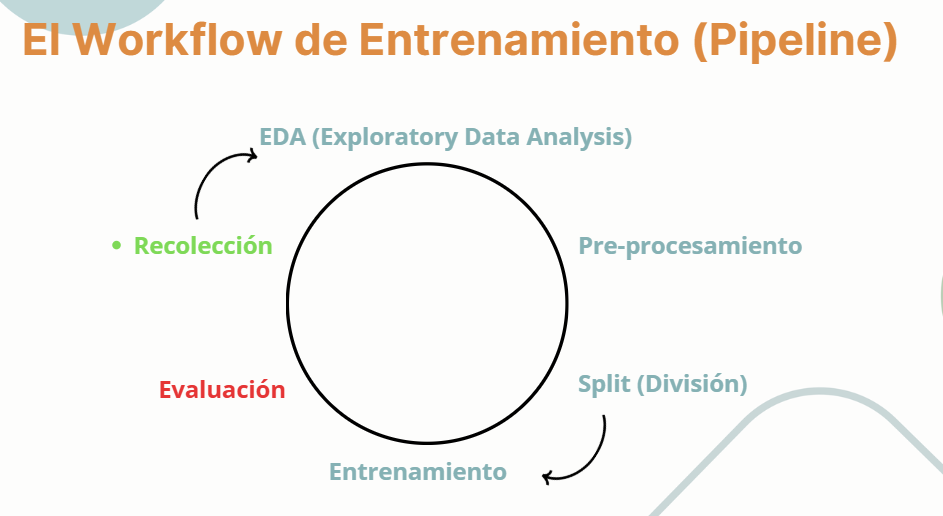

##📌 Misión

Desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

# 🧠 Objetivos del Desafío

-  Preparar los datos para el modelado (tratamiento, codificación, normalización).

-  Realizar análisis de correlación y selección de variables.

-  Entrenar dos o más modelos de clasificación.

-  Evaluar el rendimiento de los modelos con métricas.

-  Interpretar los resultados, incluyendo la importancia de las variables.

-  Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

#📌 EXTRACCIÓN

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 1. Se leen los datos y se vizualizan
df = pd.read_csv('/content/datos_tratados.csv')
df.head()

,Id,Churn,Genero,tiene +60,Tiene_pareja,Tiene_dependientes,Tiempo_contrato,servicio_telefono,multiples_lineas,Tipo_internet,...,proteccion_dispositivos,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_digital,metodo_pago,Valor_mensual,Total_cobrado,Cuentas_diarias
0,0002-ORFBO,No,Femenino,0,Si,Si,9,Si,No,DSL,...,No,Si,Si,No,Anual,Yes,Cheque,65.6,593.30,2.186667
1,0003-MKNFE,No,Masculino,0,No,No,9,Si,Si,DSL,...,No,No,No,Si,Mensual,No,Cheque,59.9,542.40,1.996667
2,0004-TLHLJ,Si,Masculino,0,No,No,4,Si,No,Fibra optica,...,Si,No,No,No,Mensual,Yes,Cheque electronico,73.9,280.85,2.463333
3,0011-IGKFF,Si,Masculino,1,Si,No,13,Si,No,Fibra optica,...,Si,No,Si,Si,Mensual,Yes,Cheque electronico,98.0,1237.85,3.266667
4,0013-EXCHZ,Si,Femenino,1,Si,No,3,Si,No,Fibra optica,...,No,Si,Si,No,Mensual,Yes,Cheque,83.9,267.40,2.796667


In [3]:
# 2. Confirmamos cuales son las columnas con las que cuenta el DF
df.columns

Index(['Id', 'Churn', 'Genero', 'tiene +60', 'Tiene_pareja',
       'Tiene_dependientes', 'Tiempo_contrato', 'servicio_telefono',
       'multiples_lineas', 'Tipo_internet', 'seguridad_online',
       'backup_online', 'proteccion_dispositivos', 'soporte_tecnico',
       'streaming_tv', 'streaming_peliculas', 'tipo_contrato',
       'facturacion_digital', 'metodo_pago', 'Valor_mensual', 'Total_cobrado',
       'Cuentas_diarias'],
      dtype='object')

In [4]:
# 3. Revisamos que tipo de datos estan en las columnas de nuestro DF
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Id                       7032 non-null   object 
 1   Churn                    7032 non-null   object 
 2   Genero                   7032 non-null   object 
 3   tiene +60                7032 non-null   int64  
 4   Tiene_pareja             7032 non-null   object 
 5   Tiene_dependientes       7032 non-null   object 
 6   Tiempo_contrato          7032 non-null   int64  
 7   servicio_telefono        7032 non-null   object 
 8   multiples_lineas         7032 non-null   object 
 9   Tipo_internet            7032 non-null   object 
 10  seguridad_online         7032 non-null   object 
 11  backup_online            7032 non-null   object 
 12  proteccion_dispositivos  7032 non-null   object 
 13  soporte_tecnico          7032 non-null   object 
 14  streaming_tv            

In [5]:
df['tiene +60'] = df['tiene +60'].replace({0 : 'No'})

In [6]:
df['tiene +60'] = df['tiene +60'].replace({1 : 'Si'})

In [7]:
df

,Id,Churn,Genero,tiene +60,Tiene_pareja,Tiene_dependientes,Tiempo_contrato,servicio_telefono,multiples_lineas,Tipo_internet,...,proteccion_dispositivos,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_digital,metodo_pago,Valor_mensual,Total_cobrado,Cuentas_diarias
0,0002-ORFBO,No,Femenino,No,Si,Si,9,Si,No,DSL,...,No,Si,Si,No,Anual,Yes,Cheque,65.60,593.30,2.186667
1,0003-MKNFE,No,Masculino,No,No,No,9,Si,Si,DSL,...,No,No,No,Si,Mensual,No,Cheque,59.90,542.40,1.996667
2,0004-TLHLJ,Si,Masculino,No,No,No,4,Si,No,Fibra optica,...,Si,No,No,No,Mensual,Yes,Cheque electronico,73.90,280.85,2.463333
3,0011-IGKFF,Si,Masculino,Si,Si,No,13,Si,No,Fibra optica,...,Si,No,Si,Si,Mensual,Yes,Cheque electronico,98.00,1237.85,3.266667
4,0013-EXCHZ,Si,Femenino,Si,Si,No,3,Si,No,Fibra optica,...,No,Si,Si,No,Mensual,Yes,Cheque,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,No,Femenino,No,No,No,13,Si,No,DSL,...,No,Si,No,No,Anual,No,Cheque,55.15,742.90,1.838333
7028,9992-RRAMN,Si,Masculino,No,Si,No,22,Si,Si,Fibra optica,...,No,No,No,Si,Mensual,Yes,Cheque electronico,85.10,1873.70,2.836667
7029,9992-UJOEL,No,Masculino,No,No,No,2,Si,No,DSL,...,No,No,No,No,Mensual,Yes,Cheque,50.30,92.75,1.676667
7030,9993-LHIEB,No,Masculino,No,Si,Si,67,Si,No,DSL,...,Si,Si,No,Si,Dos años,No,Cheque,67.85,4627.65,2.261667


#🛠️ Pre procesamiento

✔️ Remover columnas irrelevantes

In [8]:
# 4. Se eliminan las columnas que no sirven y harian ruido a nuestro modelo (En este caso no sirve de nada el ID)
df = df.drop(columns=['Id'])


In [9]:
# 5. Verificamos que se haya eliminado correctamente la columna
df

,Churn,Genero,tiene +60,Tiene_pareja,Tiene_dependientes,Tiempo_contrato,servicio_telefono,multiples_lineas,Tipo_internet,seguridad_online,...,proteccion_dispositivos,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_digital,metodo_pago,Valor_mensual,Total_cobrado,Cuentas_diarias
0,No,Femenino,No,Si,Si,9,Si,No,DSL,No,...,No,Si,Si,No,Anual,Yes,Cheque,65.60,593.30,2.186667
1,No,Masculino,No,No,No,9,Si,Si,DSL,No,...,No,No,No,Si,Mensual,No,Cheque,59.90,542.40,1.996667
2,Si,Masculino,No,No,No,4,Si,No,Fibra optica,No,...,Si,No,No,No,Mensual,Yes,Cheque electronico,73.90,280.85,2.463333
3,Si,Masculino,Si,Si,No,13,Si,No,Fibra optica,No,...,Si,No,Si,Si,Mensual,Yes,Cheque electronico,98.00,1237.85,3.266667
4,Si,Femenino,Si,Si,No,3,Si,No,Fibra optica,No,...,No,Si,Si,No,Mensual,Yes,Cheque,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,No,Femenino,No,No,No,13,Si,No,DSL,Si,...,No,Si,No,No,Anual,No,Cheque,55.15,742.90,1.838333
7028,Si,Masculino,No,Si,No,22,Si,Si,Fibra optica,No,...,No,No,No,Si,Mensual,Yes,Cheque electronico,85.10,1873.70,2.836667
7029,No,Masculino,No,No,No,2,Si,No,DSL,No,...,No,No,No,No,Mensual,Yes,Cheque,50.30,92.75,1.676667
7030,No,Masculino,No,Si,Si,67,Si,No,DSL,Si,...,Si,Si,No,Si,Dos años,No,Cheque,67.85,4627.65,2.261667


In [10]:
# 6. Se puede notar que hay columnas que no estan de forma binaria (o en este caso en el sentido de Sí y No) por lo que habria que hacer un ajuste, pasando la tercera opción (la que es un Sin servicio de internet) a un NO
df.sample(10)

,Churn,Genero,tiene +60,Tiene_pareja,Tiene_dependientes,Tiempo_contrato,servicio_telefono,multiples_lineas,Tipo_internet,seguridad_online,...,proteccion_dispositivos,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_digital,metodo_pago,Valor_mensual,Total_cobrado,Cuentas_diarias
6275,No,Masculino,No,No,No,1,Si,Si,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mensual,Yes,Cheque,25.00,25.00,0.833333
2965,Si,Femenino,Si,Si,No,17,Si,Si,Fibra optica,Si,...,Si,No,No,No,Mensual,Yes,Transferencia bancaria,85.35,1463.45,2.845000
5276,No,Femenino,No,Si,No,72,Si,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Dos años,No,Transferencia bancaria,20.05,1423.65,0.668333
2209,No,Femenino,No,No,No,60,Si,No,Fibra optica,Si,...,Si,Si,Si,Si,Mensual,Yes,Transferencia bancaria,104.95,6236.75,3.498333
5566,Si,Masculino,No,No,No,22,Si,Si,DSL,Si,...,No,No,No,No,Mensual,No,Cheque electronico,59.00,1254.70,1.966667
6489,Si,Femenino,Si,No,No,14,Si,Si,Fibra optica,No,...,Si,No,Si,Si,Mensual,Yes,Cheque electronico,104.85,1531.40,3.495000
3798,No,Femenino,No,No,No,3,Si,Si,DSL,No,...,No,Si,Si,No,Mensual,No,Cheque electronico,64.60,174.20,2.153333
3942,Si,Femenino,Si,No,No,16,Si,Si,Fibra optica,No,...,No,No,Si,Si,Mensual,Yes,Cheque electronico,96.15,1529.20,3.205000
886,No,Femenino,No,Si,Si,72,Si,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Dos años,Yes,Cheque,20.70,1482.30,0.690000
150,No,Femenino,Si,No,No,67,Si,No,Fibra optica,Si,...,No,Si,Si,No,Dos años,Yes,Transferencia bancaria,92.45,6140.85,3.081667


In [11]:
# 7. Por medio de una trupa guardo los nombres de las columnas que se ocupan cambiar
cols_to_fix = [
    'seguridad_online', 'backup_online', 'proteccion_dispositivos',
    'soporte_tecnico', 'streaming_tv', 'streaming_peliculas'
]
# 8. Reemplazo los valores requeridos con un for que pasa por la trupa
for col in cols_to_fix:
    df[col] = df[col].replace({'Sin servicio de internet': 'No'})


In [12]:
df = df.replace({'Sin servicio de telefono' : 'No'})

In [13]:
# 9. Verifico como queda en DF
df

,Churn,Genero,tiene +60,Tiene_pareja,Tiene_dependientes,Tiempo_contrato,servicio_telefono,multiples_lineas,Tipo_internet,seguridad_online,...,proteccion_dispositivos,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_digital,metodo_pago,Valor_mensual,Total_cobrado,Cuentas_diarias
0,No,Femenino,No,Si,Si,9,Si,No,DSL,No,...,No,Si,Si,No,Anual,Yes,Cheque,65.60,593.30,2.186667
1,No,Masculino,No,No,No,9,Si,Si,DSL,No,...,No,No,No,Si,Mensual,No,Cheque,59.90,542.40,1.996667
2,Si,Masculino,No,No,No,4,Si,No,Fibra optica,No,...,Si,No,No,No,Mensual,Yes,Cheque electronico,73.90,280.85,2.463333
3,Si,Masculino,Si,Si,No,13,Si,No,Fibra optica,No,...,Si,No,Si,Si,Mensual,Yes,Cheque electronico,98.00,1237.85,3.266667
4,Si,Femenino,Si,Si,No,3,Si,No,Fibra optica,No,...,No,Si,Si,No,Mensual,Yes,Cheque,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,No,Femenino,No,No,No,13,Si,No,DSL,Si,...,No,Si,No,No,Anual,No,Cheque,55.15,742.90,1.838333
7028,Si,Masculino,No,Si,No,22,Si,Si,Fibra optica,No,...,No,No,No,Si,Mensual,Yes,Cheque electronico,85.10,1873.70,2.836667
7029,No,Masculino,No,No,No,2,Si,No,DSL,No,...,No,No,No,No,Mensual,Yes,Cheque,50.30,92.75,1.676667
7030,No,Masculino,No,Si,Si,67,Si,No,DSL,Si,...,Si,Si,No,Si,Dos años,No,Cheque,67.85,4627.65,2.261667


✔️ Verificación nuevamente de los valores nulos

In [14]:
# 10. Se verifica si es que quedaron valores nulos en el df

df.isnull().sum()

,0
Churn,0
Genero,0
tiene +60,0
Tiene_pareja,0
Tiene_dependientes,0
Tiempo_contrato,0
servicio_telefono,0
multiples_lineas,0
Tipo_internet,0
seguridad_online,0


In [15]:
for col in df.columns:
  print(f'{col}: {df[col].nunique()}')
  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-' * 50)

Churn: 2
['No' 'Si']
--------------------------------------------------
Genero: 2
['Femenino' 'Masculino']
--------------------------------------------------
tiene +60: 2
['No' 'Si']
--------------------------------------------------
Tiene_pareja: 2
['Si' 'No']
--------------------------------------------------
Tiene_dependientes: 2
['Si' 'No']
--------------------------------------------------
Tiempo_contrato: 72
servicio_telefono: 2
['Si' 'No']
--------------------------------------------------
multiples_lineas: 2
['No' 'Si']
--------------------------------------------------
Tipo_internet: 3
['DSL' 'Fibra optica' 'No']
--------------------------------------------------
seguridad_online: 2
['No' 'Si']
--------------------------------------------------
backup_online: 2
['Si' 'No']
--------------------------------------------------
proteccion_dispositivos: 2
['No' 'Si']
--------------------------------------------------
soporte_tecnico: 2
['Si' 'No']
-----------------------------------

# 📊 EDA

✔️ Correlación entre variables numericas

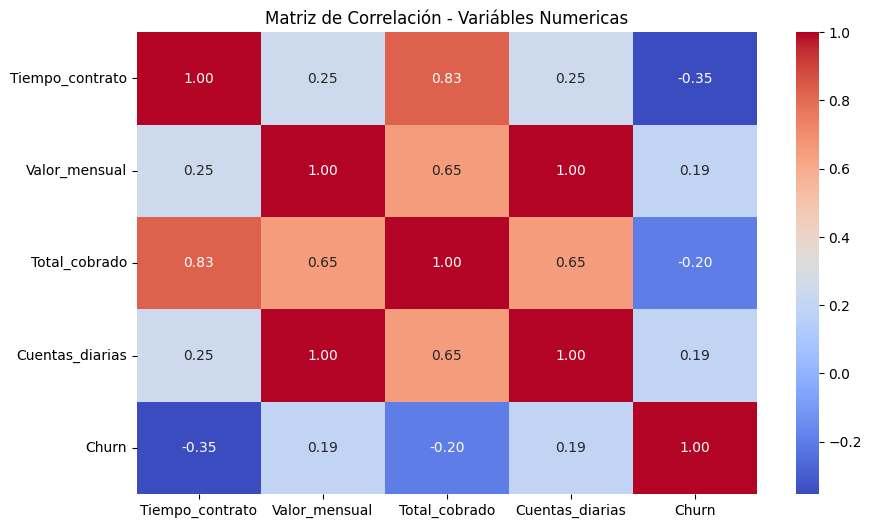

In [16]:
df_numeric = df.select_dtypes(include=["int64", "float64"])

df_numeric["Churn"] = df["Churn"].map({"Si": 1, "No": 0})

corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()


Se puede observar que existe una leve correlación negativa entre el tiempo de contrato y Churn lo que indica que entre mayor tiempo de contrato menor probabilidad de que las personas cancelen el servicio (Churn)

In [17]:
df = df.drop(columns=["Cuentas_diarias","Total_cobrado"])

2️⃣ Analisis de churn por categoria (variables categoricas)

🔹 Seleccionar variables categoricas

In [18]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")


🔹 Tabla de proporción por categoria

In [19]:
for col in categorical_cols:
    print(f"\n📌 Analisis de variable: {col}")
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)



📌 Analisis de variable: Genero


Churn,No,Si
Genero,,
Femenino,73.040482,26.959518
Masculino,73.795435,26.204565



📌 Analisis de variable: tiene +60


Churn,No,Si
tiene +60,,
No,76.349745,23.650255
Si,58.318739,41.681261



📌 Analisis de variable: Tiene_pareja


...

Churn,No,Si
tipo_contrato,,
Anual,88.722826,11.277174
Dos años,97.151335,2.848665
Mensual,57.290323,42.709677



📌 Analisis de variable: facturacion_digital


Churn,No,Si
facturacion_digital,,
No,83.624302,16.375698
Yes,66.410749,33.589251



📌 Analisis de variable: metodo_pago


Churn,No,Si
metodo_pago,,
Cheque,80.798005,19.201995
Cheque electronico,54.714588,45.285412
Tarjeta de credito,84.746877,15.253123
Transferencia bancaria,83.268482,16.731518


Lo que se puede apreciar con estos reportes es que hay ciertos elementos que son impactantes, los cuales son:

-  tiene +60: Ya que si la persona en efecto tiene +60 hay un 41% de personas registradas que dieron de baja el servicio (Churn)
-  Tipo de internet: **(Fibra Optica)** ya que de las personas registradas un 41% dio de baja el servicio contando con el servicio de fibra optica
-  tipo_contrato: **(Mensual)** las personas con este tipo de contrato tienen un 42% de darse de baja (Churn)
-  Metodo_pago: **(Cheque electronico)** las personas con este tipo de pago tienen un 45% de dar de baja el servicio (Churn)

🎯 Metodo recomendado: Qui-cuadrado (Chi-Square Test)

In [20]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crea copia
df_rank = df.copy()

# Convertir Churn para binario
df_rank["Churn"] = df_rank["Churn"].map({"Si": 1, "No": 0})

# Separar variables categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar teste Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importancia
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df


,Variable,Chi2 Score,p-value
13,tipo_contrato,392.706273,2.131687e-87
7,seguridad_online,147.165601,7.219883e-34
10,soporte_tecnico,135.439602,2.645952e-31
1,tiene +60,133.482766,7.089546e-31
3,Tiene_dependientes,131.271509,2.159540e-30
14,facturacion_digital,104.979224,1.234232e-24
2,Tiene_pareja,81.857769,1.462409e-19
15,metodo_pago,65.322209,6.360052e-16
8,backup_online,31.209832,2.315902e-08
9,proteccion_dispositivos,20.216007,6.917171e-06


In [21]:
significant_vars = chi_df[chi_df["p-value"] < 0.05]

print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)


✅ Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
13,tipo_contrato,392.706273,2.131687e-87
7,seguridad_online,147.165601,7.219883e-34
10,soporte_tecnico,135.439602,2.645952e-31
1,tiene +60,133.482766,7.089546e-31
3,Tiene_dependientes,131.271509,2.159540e-30
14,facturacion_digital,104.979224,1.234232e-24
2,Tiene_pareja,81.857769,1.462409e-19
15,metodo_pago,65.322209,6.360052e-16
8,backup_online,31.209832,2.315902e-08
9,proteccion_dispositivos,20.216007,6.917171e-06


In [22]:
df = df.drop(columns = ["Genero", "servicio_telefono"])

#🎯 Split

In [23]:
X = df.drop('Churn', axis = 1)
y = df ['Churn']

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,stratify=y, random_state=42)

# 3. One Hot Encoding

In [26]:
# Aplicar One Hot Encoding
X_train = pd.get_dummies(X_train, drop_first = True)

#Aplicar en Test
X_test = pd.get_dummies(X_test, drop_first=True)

#Garantizar que Train y Test tengas las mismas columnas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [27]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5625 entries, 1416 to 1465
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Tiempo_contrato                     5625 non-null   int64  
 1   Valor_mensual                       5625 non-null   float64
 2   tiene +60_Si                        5625 non-null   bool   
 3   Tiene_pareja_Si                     5625 non-null   bool   
 4   Tiene_dependientes_Si               5625 non-null   bool   
 5   multiples_lineas_Si                 5625 non-null   bool   
 6   Tipo_internet_Fibra optica          5625 non-null   bool   
 7   Tipo_internet_No                    5625 non-null   bool   
 8   seguridad_online_Si                 5625 non-null   bool   
 9   backup_online_Si                    5625 non-null   bool   
 10  proteccion_dispositivos_Si          5625 non-null   bool   
 11  soporte_tecnico_Si                  5625 non-

In [28]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1407 entries, 984 to 2092
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Tiempo_contrato                     1407 non-null   int64  
 1   Valor_mensual                       1407 non-null   float64
 2   tiene +60_Si                        1407 non-null   bool   
 3   Tiene_pareja_Si                     1407 non-null   bool   
 4   Tiene_dependientes_Si               1407 non-null   bool   
 5   multiples_lineas_Si                 1407 non-null   bool   
 6   Tipo_internet_Fibra optica          1407 non-null   bool   
 7   Tipo_internet_No                    1407 non-null   bool   
 8   seguridad_online_Si                 1407 non-null   bool   
 9   backup_online_Si                    1407 non-null   bool   
 10  proteccion_dispositivos_Si          1407 non-null   bool   
 11  soporte_tecnico_Si                  1407 non-n

# 4. Verificar el desbalanceamiento

In [ ]:
'''
significant_vars = chi_df[chi_df["p-value"] < 0.05]

print("📊 Ranking completo:")
display(chi_df)

print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)

selected_features = significant_vars["Variable"].tolist()

print("\n🎯 Variables seleccionadas:")
print(selected_features)
'''

📊 Ranking completo:


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06



✅ Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06



🎯 Variables seleccionadas:
['Contract', 'OnlineSecurity', 'TechSupport', 'SeniorCitizen', 'Dependents', 'PaperlessBilling', 'Partner', 'PaymentMethod', 'OnlineBackup', 'DeviceProtection', 'StreamingTV', 'StreamingMovies', 'InternetService', 'MultipleLines']


In [29]:
y_train.value_counts(normalize=True) * 100

,proportion
Churn,
No,73.422222
Si,26.577778


# Entrenamiento

## Modelo 1 - Regresión Logística

Regresión logística
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1033
          Si       0.65      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



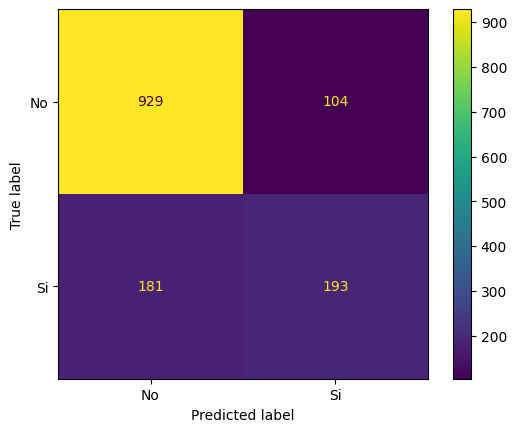

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

log_model = LogisticRegression(max_iter = 1000)
log_model.fit(X_train, y_train)

y_pred_log_normal = log_model.predict(X_test)

print('Regresión logística')
print(classification_report(y_test,y_pred_log_normal))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_log_normal);


**Se puede apreciar con el cuadro anterior que el recall es de 52% por lo que tiene un amplio margen de mejora, ya que solo puede predecir correctamente eso y los restantes 48% no tiene idea de si seran clientes churn o no**

## Modelo 2 - Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print('Random Forest')
print(classification_report(y_test,y_pred_rf))

Random Forest
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1033
          Si       0.64      0.51      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.80      0.79      1407



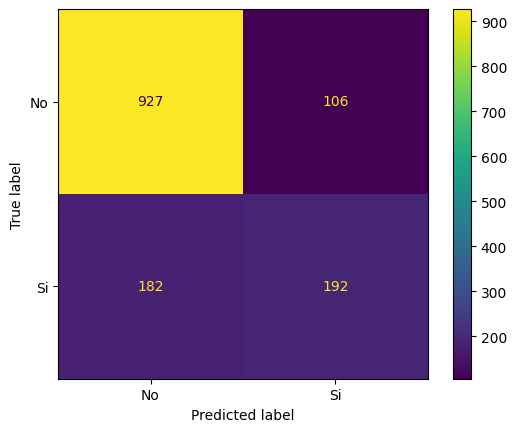

In [40]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf);

**El modelo anterior es incluso un poco mas complicado, ya que tiene datos con peores cifras en el recall y se aprecia mejor en el grafico**

## Modelo 3 - Regresión Logística

In [34]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter = 1000, class_weight = 'balanced')
log_model.fit(X_train,y_train)

y_pred_log = log_model.predict(X_test)

print(classification_report(y_test,y_pred_log))

              precision    recall  f1-score   support

          No       0.91      0.73      0.81      1033
          Si       0.52      0.79      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



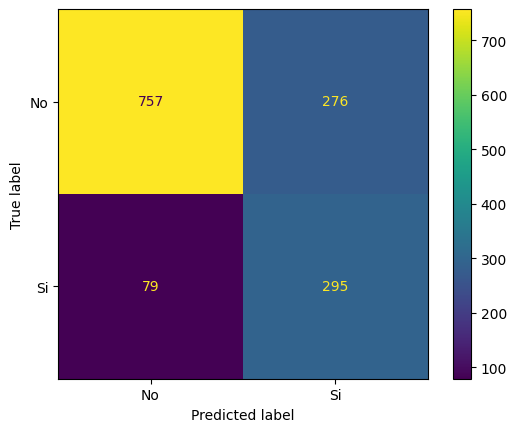

In [38]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_log);

Este modelo parece ser el ganador, debido a que mantiene un recall decente de 73% y 79% en su precisión con respecto al **Si**, que es el valor importante debido a que tratamos de predecir cuales de los clientes son más propensos a Churn

# Conclusión final

El modelo que se selecciono para predecir el Churn fue el de **Regresión Logistica **, ya que presento un mejor desempeño en el **Recall**

Los principales factores que influyen en la cancelación de servicios, según el análisis de significancia y el rendimiento de los modelos, incluyen:

-  Tipo de Contrato: Los contratos mensuales suelen tener mayor riesgo de churn.
-  Servicios Adicionales: La presencia o ausencia de servicios como seguridad_online, soporte_tecnico, backup_online, proteccion_dispositivos, streaming_tv, y streaming_peliculas son determinantes.
-  Demografía del Cliente: tiene +60, Tiene_dependientes y Tiene_pareja influyen en la probabilidad de churn.
-  Facturación Digital: Clientes con facturación digital muestran patrones específicos de churn.
-  Método de Pago: Ciertos métodos de pago pueden estar asociados con una mayor o menor propensión a cancelar.
-  Tipo de Internet: El servicio de Fibra Óptica parece tener un impacto en el churn.

**La empresa debería enfocar sus esfuerzos de retención en clientes con contratos mensuales (algun tipo de promoción), y analizar la oferta y valor percibido de los servicios adicionales (revisar el servicio de fibra optica), así como las opciones de pago (una investigación para ver porque el pago por cheque electronico genera tanto disguto al punto de dar de baja el servicio) y la segmentación demográfica (campañas con las personas mayores de 60, una suposición es que puede que batallen con la tecnologia) para anticipar y mitigar el churn.**